In [1]:
# source /data/Xilinx_no_Vitis/Vivado/2020.1/settings64.sh
!vivado -version

Vivado v2020.1.1 (64-bit)
SW Build 2960000 on Wed Aug  5 22:57:21 MDT 2020
IP Build 2956692 on Thu Aug  6 01:41:30 MDT 2020
Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.


In [2]:
import os 
import pickle
import hashlib

import pandas as pd

import hls4ml 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import accuracy_score
import keras
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy, BinaryCrossentropy 

from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning
import tensorflow_model_optimization as tfmot

from qkeras.qlayers import QDense, QActivation
from qkeras import QBatchNormalization
from qkeras.quantizers import quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects

os.environ['PATH'] = os.environ['XILINX_VIVADO'] + '/bin:' + os.environ['PATH']
keras.utils.set_random_seed(32)

2024-10-11 11:33:37.209080: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-11 11:33:37.223529: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-11 11:33:37.380261: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-11 11:33:37.381450: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-11 11:33:38.115166: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'


/home/giuseppe/miniconda3/envs/ml4qick-env/lib/python3.8/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


## Setup data

In [3]:
#dataset_date = '20230529'
dataset_date = '20240528'

In [4]:
#train_data_dir = "../data/malab_05282024/npz/"
#test_data_dir = "../data/malab_05282024/npz/"
train_data_dir = f'../data/qick_data/{dataset_date}/000_770/'
test_data_dir = f'../data/qick_data/{dataset_date}/000_770/'
start_location = 100
window_size = 400
end_window = start_location + window_size # 500

In [5]:
"""Loadning training split"""
#x_train_path = os.path.join(train_data_dir, f'0528_X_train_0_770.npy')
#y_train_path = os.path.join(train_data_dir, f'0528_y_train_0_770.npy')
x_train_path = os.path.join(train_data_dir, f'X_train_000_770.npy')
y_train_path = os.path.join(train_data_dir, f'y_train_000_770.npy')

assert os.path.exists(x_train_path), f"ERROR: File {x_train_path} does not exist."
assert os.path.exists(y_train_path), f"ERROR: File {y_train_path} does not exist."

X_train_val = np.load(x_train_path)
y_train_val = np.load(y_train_path)

# Insure same dataset is loaded
if dataset_date == '20240528':
    assert hashlib.md5(X_train_val).hexdigest() == 'b61226c86b7dee0201a9158455e08ffb',  "Checksum failed. Wrong file was loaded or file may be corrupted."
    assert hashlib.md5(y_train_val).hexdigest() == 'c59ce37dc7c73d2d546e7ea180fa8d31',  "Checksum failed. Wrong file was loaded or file may be corrupted."
else:
    assert hashlib.md5(X_train_val).hexdigest() == '0ab0f60cc85484a09ac3a963dff3f2b6',  "Checksum failed. Wrong file was loaded or file may be corrupted."
    assert hashlib.md5(y_train_val).hexdigest() == '4fd659c18a973f4742cb25fdca75f8b8',  "Checksum failed. Wrong file was loaded or file may be corrupted."

# Get readout window
X_train_val = X_train_val[:,start_location*2:end_window*2]
assert len(X_train_val[0]) == (end_window-start_location)*2, f"ERROR: X_test sample size {len(X_train_val[0])} does not match (start window, end window) ({start_location},{end_window}) size."


print("Train Data Set:")
print(f"  X Path : {x_train_path}")
print(f"  y Path : {y_train_path}")
print(f"  Size : {len(X_train_val):,}")
print(f"  Shape : {X_train_val[0].shape}")

Train Data Set:
  X Path : ../data/qick_data/20240528/000_770/X_train_000_770.npy
  y Path : ../data/qick_data/20240528/000_770/y_train_000_770.npy
  Size : 900,000
  Shape : (800,)


In [6]:
"""Loading testing split"""
#x_test_path = os.path.join(test_data_dir, f'0528_X_test_0_770.npy')
#y_test_path = os.path.join(test_data_dir, f'0528_y_test_0_770.npy')
x_test_path = os.path.join(train_data_dir, f'X_test_000_770.npy')
y_test_path = os.path.join(train_data_dir, f'y_test_000_770.npy')

assert os.path.exists(x_test_path), f"ERROR: File {x_test_path} does not exist."
assert os.path.exists(y_test_path), f"ERROR: File {y_test_path} does not exist."

X_test = np.load(x_test_path)
y_test = np.load(y_test_path)

# Insure same dataset is loaded
if dataset_date == '20240528':
    assert hashlib.md5(X_test).hexdigest() == 'b7d85f42522a0a57e877422bc5947cde', "Checksum failed. Wrong file was loaded or file may be corrupted."
    assert hashlib.md5(y_test).hexdigest() == '8c9cce1821372380371ade5f0ccfd4a2', "Checksum failed. Wrong file was loaded or file may be corrupted."
else:
    assert hashlib.md5(X_test).hexdigest() == '678ec7a77105a7c05d7b269ee0ce57ec', "Checksum failed. Wrong file was loaded or file may be corrupted."
    assert hashlib.md5(y_test).hexdigest() == 'fdc9fe7b08d38399e70824eb131f8d07', "Checksum failed. Wrong file was loaded or file may be corrupted."

# Get readout window
X_test = X_test[:,start_location*2:end_window*2]
assert len(X_test[0]) == (end_window-start_location)*2, f"ERROR: X_test sample size {len(X_test[0])} does not match (start window, end window) ({start_location},{end_window}) size."


print("Test Data Set:")
print(f"  X Path : {x_test_path}")
print(f"  y Path : {y_test_path}")
print(f"  Size : {len(X_test):,}" )
print(f"  Sample Shape : {X_test[0].shape}")

Test Data Set:
  X Path : ../data/qick_data/20240528/000_770/X_test_000_770.npy
  y Path : ../data/qick_data/20240528/000_770/y_test_000_770.npy
  Size : 100,000
  Sample Shape : (800,)


## Build our model 
QKeras is "Quantized Keras" for deep heterogeneous quantization of ML models. We're using QDense layer instead of Dense. We're also training with model sparsity, since QKeras layers are prunable.

In [7]:
hidden_neurons = 4
input_shape = int((end_window-start_location)*2)

In [32]:
def get_model(input_shape, hidden=8, is_pruned=True, activation='sigmoid'):
    model = keras.models.Sequential()
    model.add(QDense(
        hidden, 
        activation='relu', 
        name='fc1',
        input_shape=(input_shape,), 
        kernel_quantizer=quantized_bits(4,0,alpha=1), bias_quantizer=quantized_bits(4,0,alpha=1)
        #kernel_quantizer=quantized_bits(6,0,alpha=1), bias_quantizer=quantized_bits(6,0,alpha=1)
    ))
    model.add(BatchNormalization(name='batchnorm1'))
    # model.add(QBatchNormalization(
    #         name='batchnorm1',
    #         gamma_quantizer=quantized_bits(6, 0, 1),
    #         mean_quantizer=quantized_bits(6, 0, 1),
    #         variance_quantizer=quantized_bits(6, 0, 1),
    #         beta_quantizer=quantized_bits(6, 0, 1),
    # ))
    model.add(
        QDense(1, name='fc2', activation=activation, kernel_quantizer=quantized_bits(6,0,alpha=1), bias_quantizer=quantized_bits(6,0,alpha=1))
    )

    if is_pruned == True:
        # adding pruning 
        pruning_params = {'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.10, final_sparsity=0.50, begin_step=100, end_step=500)}
        model = prune.prune_low_magnitude(model, **pruning_params)
    return model


model = get_model(input_shape=input_shape, hidden=hidden_neurons, is_pruned=False)
print(model.summary())
print('Input shape:', input_shape)
print('Number of hidden neurons:', hidden_neurons)

/home/giuseppe/miniconda3/envs/ml4qick-env/lib/python3.8/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (QDense)                (None, 4)                 3204      
                                                                 
 batchnorm1 (BatchNormaliza  (None, 4)                 16        
 tion)                                                           
                                                                 
 fc2 (QDense)                (None, 1)                 5         
                                                                 
Total params: 3225 (12.60 KB)
Trainable params: 3217 (12.57 KB)
Non-trainable params: 8 (32.00 Byte)
_________________________________________________________________
None
Input shape: 800
Number of hidden neurons: 4


## Training 

In [33]:
init_learning_rate = 1e-3
validation_split = 0.05  # 45,000 sample size 
batch_size = 256
epochs = 100
early_stopping_patience = 20
checkpoint_dir = f'../checkpoints/scan_window_location_and_size_h{hidden_neurons}'
checkpoint_filename = 'qkeras_model_best.h5'

if os.path.exists(checkpoint_dir) == False:
    print(f'Checkpoint directory {checkpoint_dir} does not exist.')
    print('Creating directory...')
    os.mkdir(checkpoint_dir)

In [34]:
#########################
# 0. init callbacks
#########################
ckp_dir = os.path.join(checkpoint_dir, f'sl{start_location}_ws{window_size}')
if os.path.exists(ckp_dir) == False: os.mkdir(ckp_dir)
print('Saving to', ckp_dir)

ckp_filename = os.path.join(ckp_dir, checkpoint_filename)
callbacks = [
    ModelCheckpoint(
        ckp_filename,
        monitor="val_loss",
        verbose=0,
        save_best_only=True,
        save_weights_only=True,
        save_freq="epoch",
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=early_stopping_patience,
        restore_best_weights=False,
    ),
]


Saving to ../checkpoints/scan_window_location_and_size_h4/sl100_ws400


In [35]:
if True:
    #########################
    # 1. declare model 
    #########################
    opt = Adam(learning_rate=init_learning_rate)
    model = get_model(input_shape=window_size*2, hidden=hidden_neurons, is_pruned=False, activation='sigmoid')
    model.compile(
        optimizer=opt, 
        loss=BinaryCrossentropy(from_logits=False), 
        metrics=['accuracy']
    )

    #########################
    # 2. train 
    #########################
    history = model.fit(
        X_train_val, 
        y_train_val, 
        batch_size=batch_size,
        epochs=epochs, 
        validation_split=validation_split, 
        shuffle=True, 
        callbacks=callbacks,
    )

    # Save the history dictionary
    with open(os.path.join(ckp_dir, 'qkeras_training_history.pkl'), 'wb') as f:
        pickle.dump(history.history, f)

    #########################
    # 3. compute fidelity 
    #########################
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, np.where(y_pred <= 0.5, 0, 1).reshape(-1))

    print('\n===================================')
    print(f'Start location = {start_location}, Window size = {window_size}')
    print('    Accuracy', test_acc)
    print('    Fidelity', test_acc*2-1)


Epoch 1/100
3340/3340 [==============================] - 10s 3ms/step - loss: 0.1872 - accuracy: 0.9546 - val_loss: 0.1746 - val_accuracy: 0.9578
Epoch 2/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1752 - accuracy: 0.9601 - val_loss: 0.1736 - val_accuracy: 0.9583
Epoch 3/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1743 - accuracy: 0.9604 - val_loss: 0.1739 - val_accuracy: 0.9584
Epoch 4/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1739 - accuracy: 0.9606 - val_loss: 0.1729 - val_accuracy: 0.9589
Epoch 5/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1734 - accuracy: 0.9608 - val_loss: 0.1731 - val_accuracy: 0.9590
Epoch 6/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1732 - accuracy: 0.9611 - val_loss: 0.1723 - val_accuracy: 0.9590
Epoch 7/100
3340/3340 [==============================] - 5s 1ms/step - loss: 0.1730 - accuracy: 0.9611 - val_loss: 0.1731 - val_a

## Check performance

In [12]:
ckp_filename = os.path.join(ckp_dir, checkpoint_filename)
ckp_filename

'../checkpoints/scan_window_location_and_size_h4/sl100_ws400/qkeras_model_best.h5'

In [13]:
checkpoint_model = get_model(input_shape=input_shape, hidden=hidden_neurons, is_pruned=False, activation='sigmoid')
checkpoint_model.load_weights(ckp_filename)

y_pred = checkpoint_model.predict(X_test)
test_acc = accuracy_score(y_test, np.where(y_pred < 0.5, 0, 1).reshape(-1))

print(f"Keras  Accuracy (with sigmoid): {test_acc}")
print(f"Keras  Fidelity (with sigmoid): {test_acc*2-1}")

checkpoint_model = get_model(input_shape=input_shape, hidden=hidden_neurons, is_pruned=False, activation=None)
checkpoint_model.load_weights(ckp_filename)

y_pred = checkpoint_model.predict(X_test)
test_acc = accuracy_score(y_test, np.where(y_pred < 0.5, 0, 1).reshape(-1))

print(f"Keras  Accuracy (w/o sigmoid): {test_acc}")
print(f"Keras  Fidelity (w/o sigmoid): {test_acc*2-1}")

3125/3125 [==============================] - 2s 767us/step
Keras  Accuracy (with sigmoid): 0.96083
Keras  Fidelity (with sigmoid): 0.9216599999999999
3125/3125 [==============================] - 3s 872us/step
Keras  Accuracy (w/o sigmoid): 0.96002
Keras  Fidelity (w/o sigmoid): 0.92004


## Check sparsity 

Number of layers: 3
% of zeros = 0.0
% of zeros = 0.0
% of zeros = 0.0


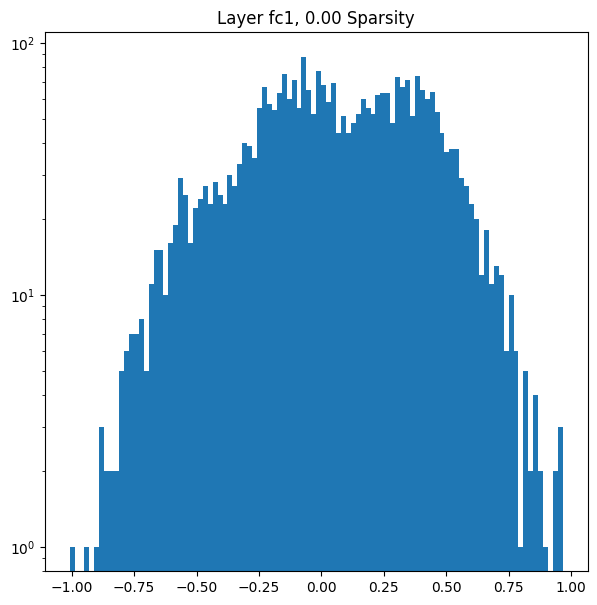

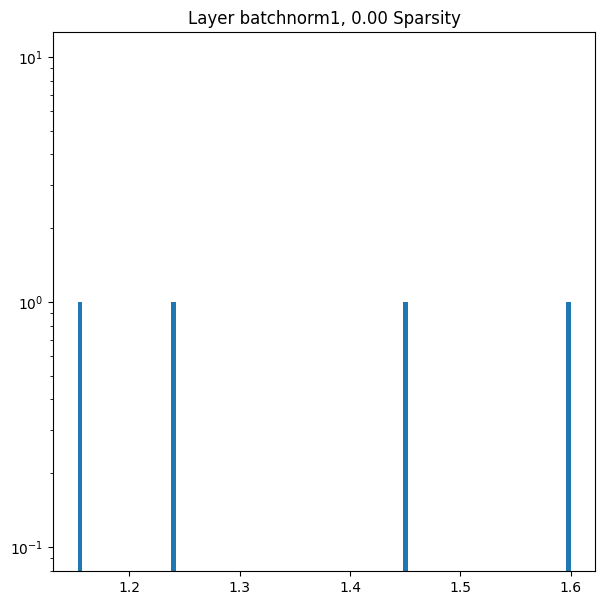

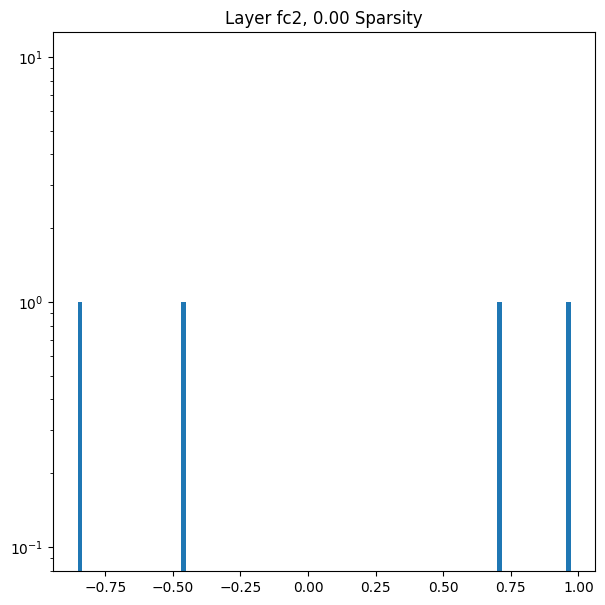

In [14]:
num_layers = len(checkpoint_model.layers)
print(f'Number of layers: {num_layers}')


for idx in range(num_layers):
    w = checkpoint_model.layers[idx].weights[0].numpy()
    h, b = np.histogram(w, bins=100)
    layer_sparsity = np.sum(w == 0) / np.size(w)

    # plot weight distribution
    plt.figure(figsize=(7, 7))
    plt.bar(b[:-1], h, width=b[1] - b[0])
    plt.semilogy()
    plt.title(f'Layer {checkpoint_model.layers[idx].name}, {layer_sparsity:.2f} Sparsity')
    plt.savefig(os.path.join(ckp_dir, f'model-dist-idx{idx}.png'))
    print('% of zeros = {}'.format(layer_sparsity))


checkpoint_model = strip_pruning(checkpoint_model)  # remove prune layers for hls4ml parsing 
checkpoint_model.save_weights(ckp_filename)  # save as weights only for keras tracing (cannot directly pass strip_pruned model)
checkpoint_model = get_model(input_shape=input_shape, hidden=hidden_neurons, is_pruned=False, activation=None)
checkpoint_model.load_weights(ckp_filename)

## HLS4ML

In [15]:
import sys 
sys.path.append("../utils")
from config import print_dict

from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects

In [16]:
# Create HLS configuration 
hls_config = {}
hls_config['Model'] = {}
hls_config['Model']['Precision'] = 'ap_fixed<16,6>'  # Default precision
hls_config['Model']['ReuseFactor'] = 64  # parallelized 
hls_config['Model']['Strategy'] = 'Resource'

hls_config['LayerName'] = {}
keras_layers = ['fc1', 'fc1_relu', 'batchnorm1', 'fc2', 'fc2_linear']
for layer in keras_layers:
    hls_config['LayerName'][layer] = {}
    hls_config['LayerName'][layer]['Precision'] = {}
    hls_config['LayerName'][layer]['Trace'] = True

# Input - ZCU216 uses 14-bit ADCS 
hls_config['LayerName']['fc1_input'] = {}
hls_config['LayerName']['fc1_input']['Precision'] = {}
hls_config['LayerName']['fc1_input']['Trace'] = False
hls_config['LayerName']['fc1_input']['Precision'] = 'ap_fixed<14,14>' 

# Fc1
hls_config['LayerName']['fc1']['Precision']['result'] = 'ap_fixed<19,18>'
hls_config['LayerName']['fc1']['accum_t'] = 'ap_fixed<19,18>'

# Fc1 activation 
hls_config['LayerName']['fc1_relu']['Precision']['result'] = 'ap_fixed<19,18>'

# Batchnormalization
hls_config['LayerName']['batchnorm1']['Precision']['scale'] = 'ap_fixed<24,8>'
hls_config['LayerName']['batchnorm1']['Precision']['bias'] = 'ap_fixed<24,8>'
hls_config['LayerName']['batchnorm1']['Precision']['result'] = 'ap_fixed<24,8>'
hls_config['LayerName']['batchnorm1']['accum_t'] = 'ap_fixed<24,8>'

# Fc2
hls_config['LayerName']['fc2']['Precision']['result'] = 'ap_fixed<10,5>'
hls_config['LayerName']['fc2']['accum_t'] = 'ap_fixed<10,5>'

# Fc2 activation 
hls_config['LayerName']['fc2_linear']['Precision']['result'] = 'ap_fixed<10,5>'

print_dict(hls_config)

Model
  Precision:         ap_fixed<16,6>
  ReuseFactor:       64
  Strategy:          Resource
LayerName
  fc1
    Precision
      result:        ap_fixed<19,18>
    Trace:           True
    accum_t:         ap_fixed<19,18>
  fc1_relu
    Precision
      result:        ap_fixed<19,18>
    Trace:           True
  batchnorm1
    Precision
      scale:         ap_fixed<24,8>
      bias:          ap_fixed<24,8>
      result:        ap_fixed<24,8>
    Trace:           True
    accum_t:         ap_fixed<24,8>
  fc2
    Precision
      result:        ap_fixed<10,5>
    Trace:           True
    accum_t:         ap_fixed<10,5>
  fc2_linear
    Precision
      result:        ap_fixed<10,5>
    Trace:           True
  fc1_input
    Precision:       ap_fixed<14,14>
    Trace:           False


### Build HLS model 

In [17]:
output_dir = f'../hls4ml_projects/sl-{start_location}_ws-{window_size}_hn-{hidden_neurons}_date-{dataset_date}'
xilinx_part = 'xczu49dr-ffvf1760-2-e'
io_type = 'io_parallel'
#io_type = 'io_stream'
clock_period = 3.225  # 3.225ns (307.2 MHz)
hls_fig = os.path.join(output_dir, 'model.png')
#backend = 'Vitis'
backend = 'VivadoAccelerator'
interface = 'axi_stream'
driver = 'python'
board = 'zcu216'

In [18]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model=checkpoint_model,
    hls_config=hls_config,
    output_dir=output_dir,
    part=xilinx_part,
    io_type=io_type,
    clock_period=clock_period,
    backend=backend,
    board=board,
    interface=interface,
    driver=driver,
    project_name='NN'
)

print(f"Creating hls4ml project directory {output_dir}")
hls_model.compile()  # Must compile for C Sim. 

# Visualize model
hls4ml.utils.plot_model(
    hls_model, show_shapes=True, show_precision=True, to_file=hls_fig 
)

Interpreting Sequential
Topology:
Layer name: fc1_input, layer type: InputLayer, input shapes: [[None, 800]], output shape: [None, 800]
Layer name: fc1, layer type: QDense, input shapes: [[None, 800]], output shape: [None, 4]
Layer name: batchnorm1, layer type: BatchNormalization, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: fc2, layer type: QDense, input shapes: [[None, 4]], output shape: [None, 1]
Creating HLS model
Creating hls4ml project directory ../hls4ml_projects/sl-100_ws-400_hn-4_date-20240528
Writing HLS project


/home/giuseppe/miniconda3/envs/ml4qick-env/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done


## Check performance

In [19]:
def save_array_to_dat(data, top_nrows, bottom_nrows, filename):
    print('Save top {} rows and bottom {} rows in file {}'.format(top_nrows, bottom_nrows, filename))
    with open(filename, 'w') as file:
        if data.ndim == 1:
            data_ = [[x] for x in data]
        else:
            data_ = data
            
        for row in data_[:top_nrows]:
            file.write(' '.join(map(str, row)) + '\n')
        for row in data_[-bottom_nrows:]:
            file.write(' '.join(map(str, row)) + '\n')

In [20]:
# Trace output 
y_hls = hls_model.predict(np.ascontiguousarray(X_test.astype(np.float32))) 

keras_acc = accuracy_score(y_test, np.where(y_pred < 0.5, 0, 1).reshape(-1))
hls_acc = accuracy_score(y_test, np.where(y_hls < 0.5, 0, 1).reshape(-1))

print(f'Keras Acc: {keras_acc*100:.5}%')
print(f'Keras Fidelity: {(keras_acc*2-1) * 100:.5}%')
print(f'HLS Acc: {hls_acc*100:.5}:%')
print(f'HLS Fidelity: {(hls_acc*2-1) * 100:.5}:%')

Keras Acc: 96.002%
Keras Fidelity: 92.004%
HLS Acc: 95.965:%
HLS Fidelity: 91.93:%


In [21]:
!rm -f X_test.dat y_test.dat y_hls.dat

In [22]:
nrows = 10

# Save X_test for testing
save_array_to_dat(X_test, nrows, nrows, "X_test.dat")
save_array_to_dat(y_test, nrows, nrows, "y_test.dat")
save_array_to_dat(y_hls, nrows, nrows, "y_hls.dat")

Save top 10 rows and bottom 10 rows in file X_test.dat
Save top 10 rows and bottom 10 rows in file y_test.dat
Save top 10 rows and bottom 10 rows in file y_hls.dat


### Collect traces and compare

In [23]:
_, hls_trace = hls_model.trace(np.ascontiguousarray(X_test.astype(np.float32))) 
keras_trace = hls4ml.model.profiling.get_ymodel_keras(checkpoint_model, X_test) 

print(f'HLS Keys: {hls_trace.keys()}')
print(f'Keras Keys: {keras_trace.keys()}')

Recompiling NN with tracing
Writing HLS project


/home/giuseppe/miniconda3/envs/ml4qick-env/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done
3125/3125 [==============================] - 4s 1ms/step
Done taking outputs for Keras model.
HLS Keys: dict_keys(['fc1', 'fc1_relu', 'batchnorm1', 'fc2'])
Keras Keys: dict_keys(['fc1', 'fc1_relu', 'batchnorm1', 'fc2'])


Layer(s): fc1 		 162.74692
hls/keras min: -71750.5/-71586.625
hls/keras max: 79212.0/79376.28125
Layer(s): fc1_relu 		 82.6639
hls/keras min: 0.0/0.0
hls/keras max: 79212.0/79376.28125
Layer(s): batchnorm1 		 0.06828449
hls/keras min: -1.27581787109375/-1.2758097648620605
hls/keras max: 7.1849365234375/7.247999668121338
Layer(s): fc2 		 0.16358478
hls/keras min: -6.65625/-7.131763935089111
hls/keras max: 12.21875/12.465972900390625


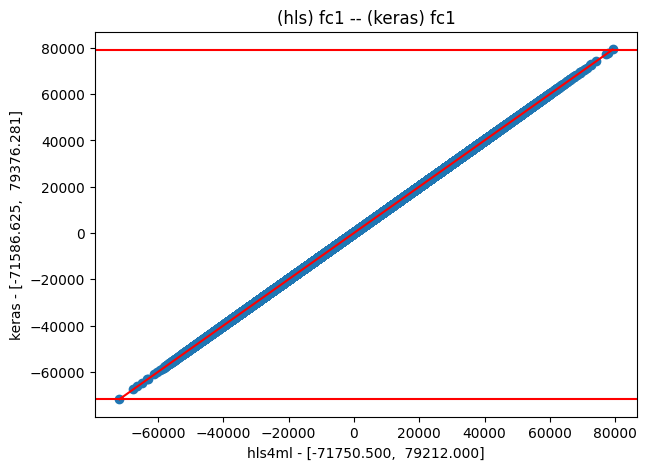

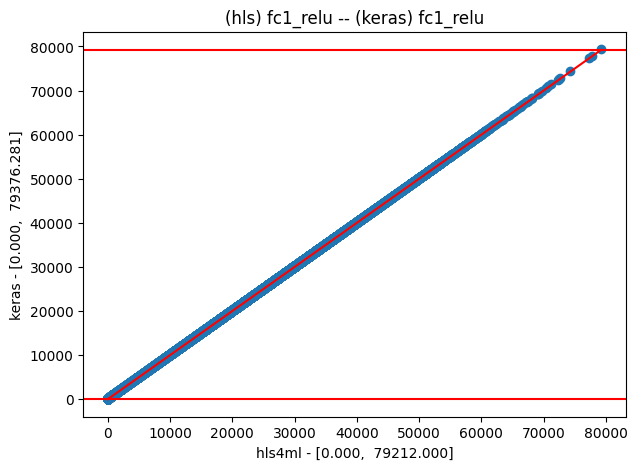

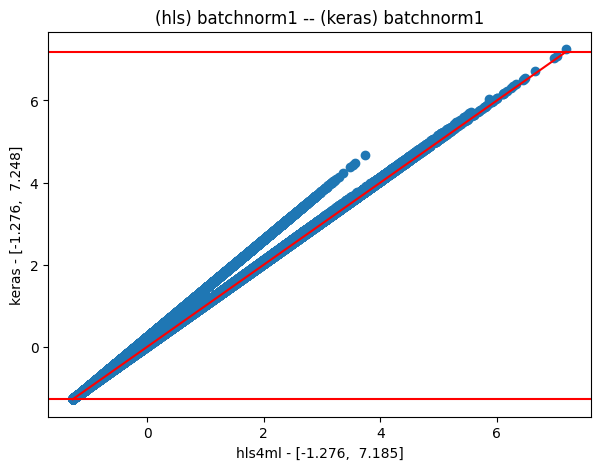

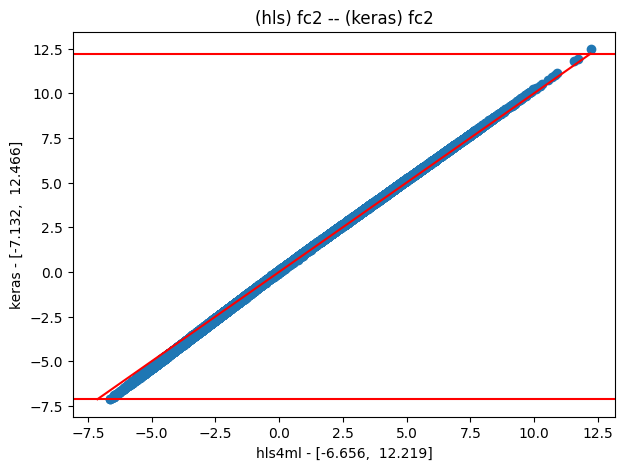

In [24]:
idx = 0

hls_layers = hls_trace.keys()
keras_layers = list(keras_trace.keys())

for layer in hls_trace.keys():
    keras_layer = layer 
    hls_layer = layer 
    keras_layer, hls_layer = keras_trace[keras_layer], hls_trace[hls_layer]
    try:
        diff = np.average(np.abs(keras_layer - hls_layer ))
        print(f'Layer(s): {list(hls_trace.keys())[idx]}', '\t\t', diff)
        
        plt.figure(figsize=(7, 5))

        plt.scatter(hls_layer.flatten(), keras_layer.flatten())
        min_x = min(keras_layer.min(), hls_layer.min())
        max_x = min(keras_layer.max(), hls_layer.max())

        onnx_min, onnx_max = keras_layer.flatten().min(), keras_layer.flatten().max()
        hls_min, hls_max = hls_layer.flatten().min(), hls_layer.flatten().max()
        
        print(f'hls/keras min: {hls_min}/{onnx_min}')
        print(f'hls/keras max: {hls_max}/{onnx_max}')
        
        plt.plot([min_x, max_x], [min_x, max_x], c='red')
        plt.axhline(min_x, c='red')
        plt.axhline(max_x, c='red')

        plt.title(f'(hls) {list(hls_trace.keys())[idx]} -- (keras) {list(keras_trace.keys())[idx]}')
        plt.xlabel(f'hls4ml - [{hls_min:.3f},  {hls_max:.3f}]')
        plt.ylabel(f'keras - [{onnx_min:.3f},  {onnx_max:.3f}]')
        plt.yscale('linear')
        idx += 1
    except Exception as e:
        print(e)


## Synthesize 

In [25]:
reports = hls_model.build(
    csim=False,
    synth=True,
    cosim=False,
    export=False,
    vsynth=True,
)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1.1 (64-bit)
  **** SW Build 2960000 on Wed Aug  5 22:57:21 MDT 2020
  **** IP Build 2956692 on Thu Aug  6 01:41:30 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: Applying HLS Y2K22 patch v1.2 for IP revision
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'giuseppe' on host 'thorin' (Linux_x86_64 version 5.14.0-1048-oem) on Fri Oct 11 11:40:18 PDT 2024
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/extras/home/gdg/research/projects/quantum/qick_dev/submodules/ml-quantum-readout/hls4ml_projects/sl-100_ws-400_hn-4_date-20240528'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/extras/home/gdg/research/projects/quantum/qick_dev/submodules/ml-quantum-readout/hls4ml_projects/sl-10

## Check the report

In [26]:
print(reports)

print('HLS')
print('   BRAM {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['CSynthesisReport']['BRAM_18K']), int(reports['CSynthesisReport']['AvailableBRAM_18K']), int(reports['CSynthesisReport']['BRAM_18K'])*100/int(reports['CSynthesisReport']['AvailableBRAM_18K'])))
print('    DSP {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['CSynthesisReport']['DSP']), int(reports['CSynthesisReport']['AvailableDSP']), int(reports['CSynthesisReport']['DSP'])*100/int(reports['CSynthesisReport']['AvailableDSP'])))
print('     FF {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['CSynthesisReport']['FF']), int(reports['CSynthesisReport']['AvailableFF']), int(reports['CSynthesisReport']['FF'])*100/int(reports['CSynthesisReport']['AvailableFF'])))
print('    LUT {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['CSynthesisReport']['LUT']), int(reports['CSynthesisReport']['AvailableLUT']), int(reports['CSynthesisReport']['LUT'])*100/int(reports['CSynthesisReport']['AvailableLUT'])))
print('SYN')
print('   BRAM {:8.2f} ({:8.2f}, {:6.2f}%)'.format(float(reports['VivadoSynthReport']['BRAM_18K']), float(reports['CSynthesisReport']['AvailableBRAM_18K']), float(reports['VivadoSynthReport']['BRAM_18K'])*100/int(reports['CSynthesisReport']['AvailableBRAM_18K'])))
print('    DSP {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['VivadoSynthReport']['DSP48E']), int(reports['CSynthesisReport']['AvailableDSP']), int(reports['VivadoSynthReport']['DSP48E'])*100/int(reports['CSynthesisReport']['AvailableDSP'])))
print('     FF {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['VivadoSynthReport']['FF']), int(reports['CSynthesisReport']['AvailableFF']), int(reports['VivadoSynthReport']['FF'])*100/int(reports['CSynthesisReport']['AvailableFF'])))
print('    LUT {:8d} ({:8d}, {:6.2f}%)'.format(int(reports['VivadoSynthReport']['LUT']), int(reports['CSynthesisReport']['AvailableLUT']), int(reports['VivadoSynthReport']['LUT'])*100/int(reports['CSynthesisReport']['AvailableLUT'])))

{'CSynthesisReport': {'TargetClockPeriod': '3.22', 'EstimatedClockPeriod': '2.768', 'BestLatency': '818', 'WorstLatency': '818', 'IntervalMin': '819', 'IntervalMax': '819', 'BRAM_18K': '0', 'DSP': '303', 'FF': '249786', 'LUT': '553952', 'URAM': '0', 'AvailableBRAM_18K': '2160', 'AvailableDSP': '4272', 'AvailableFF': '850560', 'AvailableLUT': '425280', 'AvailableURAM': '80'}, 'VivadoSynthReport': {'LUT': '81773', 'FF': '28012', 'BRAM_18K': '0', 'URAM': '0', 'DSP48E': '213'}}
HLS
   BRAM        0 (    2160,   0.00%)
    DSP      303 (    4272,   7.09%)
     FF   249786 (  850560,  29.37%)
    LUT   553952 (  425280, 130.26%)
SYN
   BRAM     0.00 ( 2160.00,   0.00%)
    DSP      213 (    4272,   4.99%)
     FF    28012 (  850560,   3.29%)
    LUT    81773 (  425280,  19.23%)


In [27]:
df_hls = pd.DataFrame([reports['CSynthesisReport']])
hls_csv_file = 'hls_report.csv'
hls_csv_file_exists = os.path.isfile(hls_csv_file)
df_hls.to_csv(hls_csv_file, mode='a', index=False, header=not hls_csv_file_exists)
df_hls_loaded = pd.read_csv(hls_csv_file)
df_hls_loaded

,TargetClockPeriod,EstimatedClockPeriod,BestLatency,WorstLatency,IntervalMin,IntervalMax,BRAM_18K,DSP,FF,LUT,URAM,AvailableBRAM_18K,AvailableDSP,AvailableFF,AvailableLUT,AvailableURAM
0,3.22,2.768,874,875,875,876,645,106,196393,205339,0,2160,4272,850560,425280,80
1,3.22,2.799,832,833,833,834,757,610,909414,1142446,0,2160,4272,850560,425280,80
2,3.22,2.768,5601,5601,5602,5602,67,410,86340,106817,0,2160,4272,850560,425280,80
3,3.22,2.768,5601,5601,5602,5602,67,410,86340,106817,0,2160,4272,850560,425280,80
4,3.22,2.768,5601,5601,5602,5602,67,410,86340,106817,0,2160,4272,850560,425280,80
5,3.22,2.768,5601,5601,5602,5602,67,401,86442,107039,0,2160,4272,850560,425280,80
6,3.22,2.768,5601,5601,5602,5602,22,129,77673,102178,0,2160,4272,850560,425280,80
7,3.22,2.768,5601,5601,5602,5602,22,129,77642,102155,0,2160,4272,850560,425280,80
8,3.22,2.768,5601,5601,5602,5602,22,129,77673,102178,0,2160,4272,850560,425280,80
9,3.22,2.801,820,820,821,821,1,14,237474,545376,0,2160,4272,850560,425280,80


In [28]:
df_syn = pd.DataFrame([reports['VivadoSynthReport']])
syn_csv_file = 'syn_report.csv'
syn_csv_file_exists = os.path.isfile(syn_csv_file)
df_syn.to_csv(syn_csv_file, mode='a', index=False, header=not syn_csv_file_exists)
df_syn_loaded = pd.read_csv(syn_csv_file)
df_syn_loaded

,LUT,FF,BRAM_18K,URAM,DSP48E
0,89713,58349,156.0,0,106
1,74760,63230,156.0,0,610
2,28193,46864,0.0,0,310
3,28193,46864,0.0,0,310
4,28193,46864,0.0,0,310
5,30325,48323,0.0,0,407
6,22875,47005,0.0,0,135
7,22276,47039,0.0,0,134
8,22875,47005,0.0,0,135
9,69693,19923,0.5,0,5


In [29]:
hls4ml.report.read_vivado_report(output_dir)

Found 1 solution(s) in ../hls4ml_projects/sl-100_ws-400_hn-4_date-20240528/NN_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vivado HLS Report for 'NN_axi'
* Date:           Fri Oct 11 15:15:02 2024

* Version:        2020.1.1 (Build 2951007 on Wed Aug 05 23:24:06 MDT 2020)
* Project:        NN_prj
* Solution:       solution1
* Product family: zynquplus
* Target device:  xczu49dr-ffvf1760-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  | 3.22 ns | 2.768 ns |   0.40 ns  |
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+------

In [30]:
!echo "$PWD/../hls4ml_projects/"
!ls "$PWD/../hls4ml_projects/"

/extras/home/gdg/research/projects/quantum/qick_dev/submodules/ml-quantum-readout/notebooks/../hls4ml_projects/
sl-100_ws-400_hn-4_date-20240528  sl-100_ws-400_hn-4_date-20240528.tar.gz


In [31]:
cat $PWD/../hls4ml_projects/sl-100_ws-400_hn-4_date-20240528/firmware/NN.cpp

#include <iostream>

#include "NN.h"
#include "parameters.h"

void NN(
    input_t fc1_input[N_INPUT_1_1],
    result_t layer5_out[N_LAYER_5]
) {

    // hls-fpga-machine-learning insert IO
    #pragma HLS ARRAY_RESHAPE variable=fc1_input complete dim=0
    #pragma HLS ARRAY_PARTITION variable=layer5_out complete dim=0
    #pragma HLS INTERFACE ap_vld port=fc1_input,layer5_out 
    #pragma HLS DATAFLOW 

#ifndef __SYNTHESIS__
    static bool loaded_weights = false;
    if (!loaded_weights) {
        // hls-fpga-machine-learning insert load weights
        nnet::load_weights_from_txt<weight2_t, 3200>(w2, "w2.txt");
        nnet::load_weights_from_txt<bias2_t, 4>(b2, "b2.txt");
        nnet::load_weights_from_txt<batchnorm1_scale_t, 4>(s4, "s4.txt");
        nnet::load_weights_from_txt<batchnorm1_bias_t, 4>(b4, "b4.txt");
        nnet::load_weights_from_txt<weight5_t, 4>(w5, "w5.txt");
        nnet::load_weights_from_txt<bias5_t, 1>(b5, "b5.txt");
        loaded_weights = true;
    }
#en